In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/zomato_user_data - LMS.csv")
print(df.head())
print(df.info())
print(df.describe(include='all'))


     user_id       city device_type subscription_status user_segment_label  \
0  ZOM200000  Hyderabad         iOS                 NaN          Returning   
1  ZOM200001    Kolkata         iOS                 NaN          Returning   
2  ZOM200002    Kolkata     Android         Zomato Gold          Returning   
3  ZOM200003  Hyderabad     Android         Zomato Gold          Returning   
4  ZOM200004  Bangalore     Android                 NaN          Long-Term   

  preferred_cuisine  app_opens_per_month  avg_session_duration_minutes  \
0      North Indian            26.740168                      8.965961   
1           Chinese            10.145544                      6.343538   
2           Italian            23.190429                      7.971666   
3      South Indian            13.083080                      6.911308   
4          Desserts            61.488038                     16.936118   

   browse_sessions_without_order  orders_per_month  ...  discount_usage_rate  \
0     


--- Q1: Exploratory Data Analysis ---


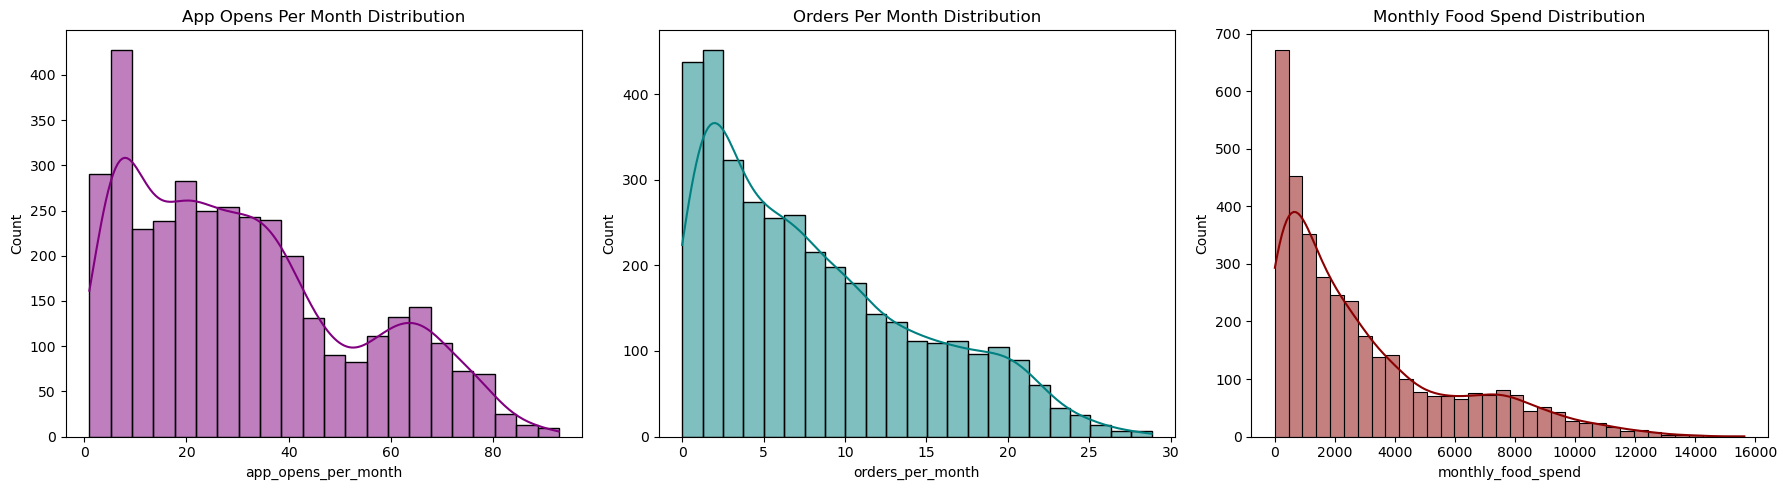

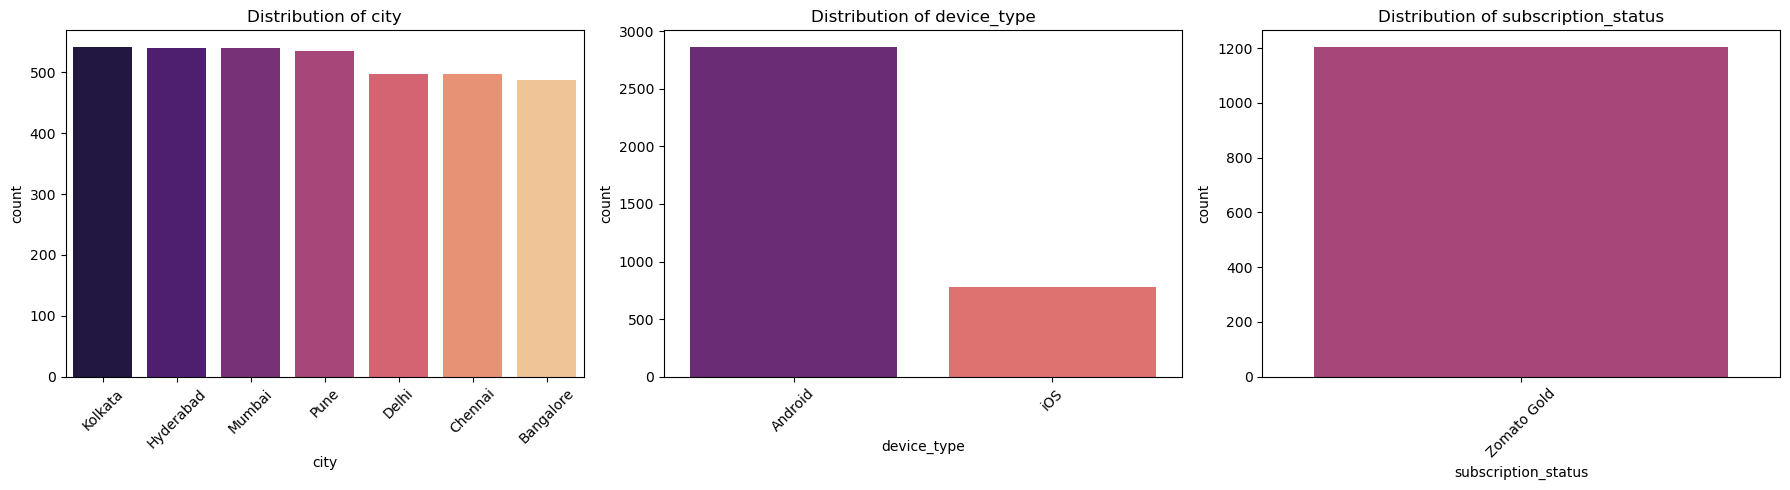

In [9]:
print("\n--- Q1: Exploratory Data Analysis ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['app_opens_per_month'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('App Opens Per Month Distribution')

sns.histplot(df['orders_per_month'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Orders Per Month Distribution')

sns.histplot(df['monthly_food_spend'], kde=True, ax=axes[2], color='darkred')
axes[2].set_title('Monthly Food Spend Distribution')
plt.tight_layout()
plt.show()


categorical_vars = ['city', 'device_type', 'subscription_status']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_vars):
    sns.countplot(data=df, x=col, ax=axes[i], palette='magma', order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


--- Q2: Data Preparation ---
Duplicate records found and removed: 0

Missing values before treatment:
 Series([], dtype: int64)

Detected Outliers (IQR Method):
 avg_session_duration_minutes       9
browse_sessions_without_order     32
orders_per_month                   8
avg_order_value                   34
monthly_food_spend               121
discount_usage_rate               26
promo_orders_ratio                16
weekend_order_ratio               44
late_night_orders_ratio           21
peak_hour_orders_ratio            19
days_since_last_order            384
avg_delivery_time_minutes         20
order_cancellation_rate           14
app_rating_given                  20
customer_support_chats            82
dtype: int64


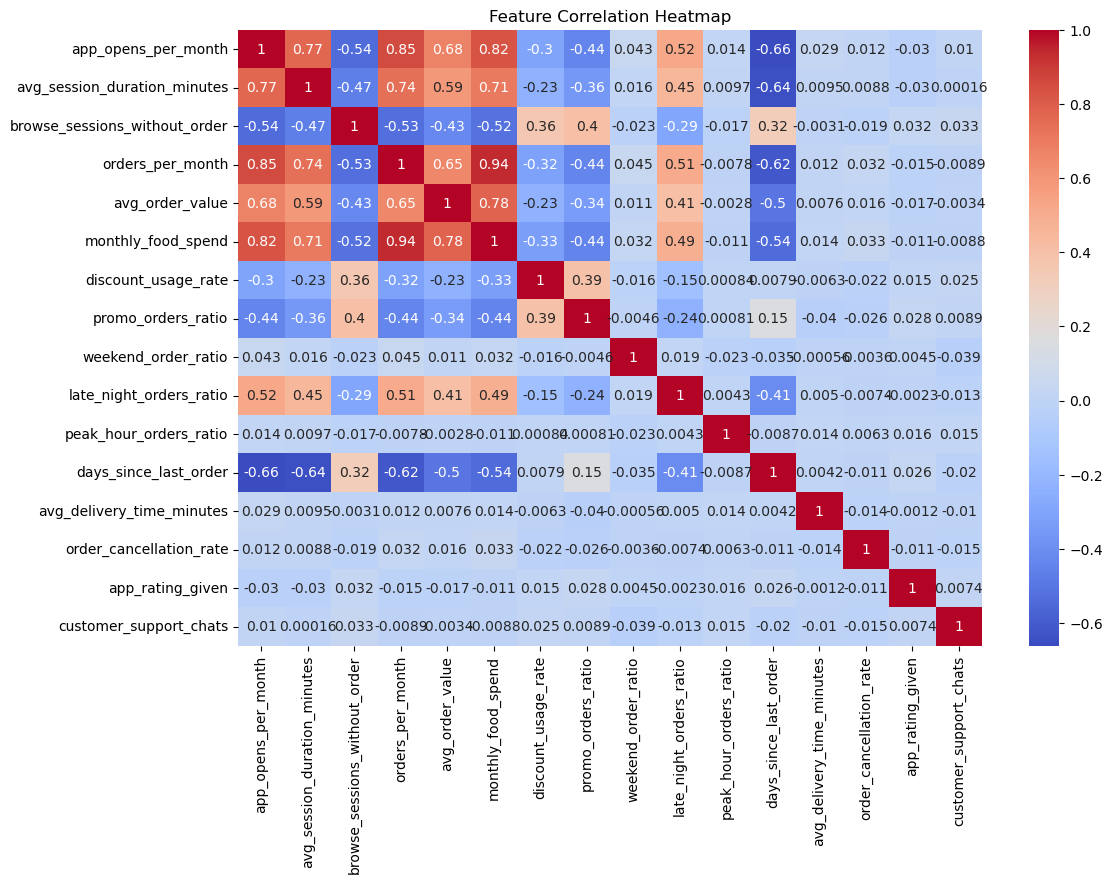

In [18]:
print("\n--- Q2: Data Preparation ---")

duplicate_count = df.duplicated().sum()
print(f"Duplicate records found and removed: {duplicate_count}")
df.drop_duplicates(inplace=True)

missing_counts = df.isnull().sum()
print("\nMissing values before treatment:\n", missing_counts[missing_counts > 0])

df['subscription_status'].fillna('Inactive', inplace=True)

df['preferred_cuisine'].fillna(df['preferred_cuisine'].mode()[0], inplace=True)

num_impute_cols = ['avg_order_value', 'discount_usage_rate', 'avg_delivery_time_minutes']
for col in num_impute_cols:
    df[col].fillna(df[col].median(), inplace=True)


num_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()
print("\nDetected Outliers (IQR Method):\n", outliers[outliers > 0])

plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
np.round(corr_matrix,2)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()



In [20]:
print("\n--- Q3: Dimensionality Reduction (PCA) ---")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original Feature Dimensionality: {X_scaled.shape[1]}")
print(f"Reduced Dimensionality (PCA): {X_pca.shape[1]}")
print(f"Total Variance Retained: {pca.explained_variance_ratio_.sum() * 100:.2f}%")


--- Q3: Dimensionality Reduction (PCA) ---
Original Feature Dimensionality: 16
Reduced Dimensionality (PCA): 11
Total Variance Retained: 91.64%



--- Q4: Clustering (K-Means) ---


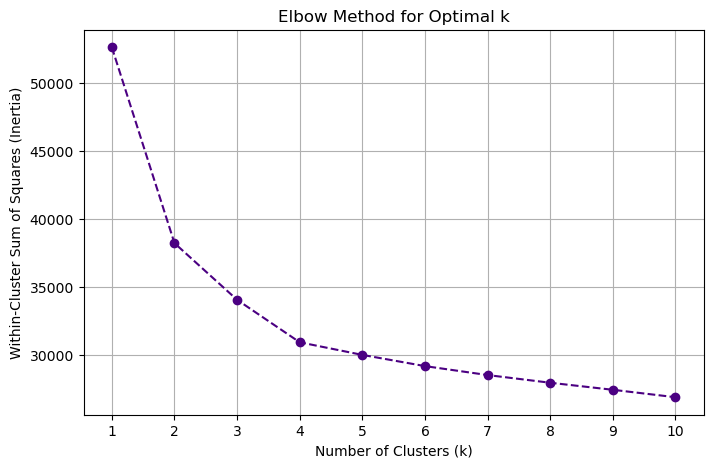

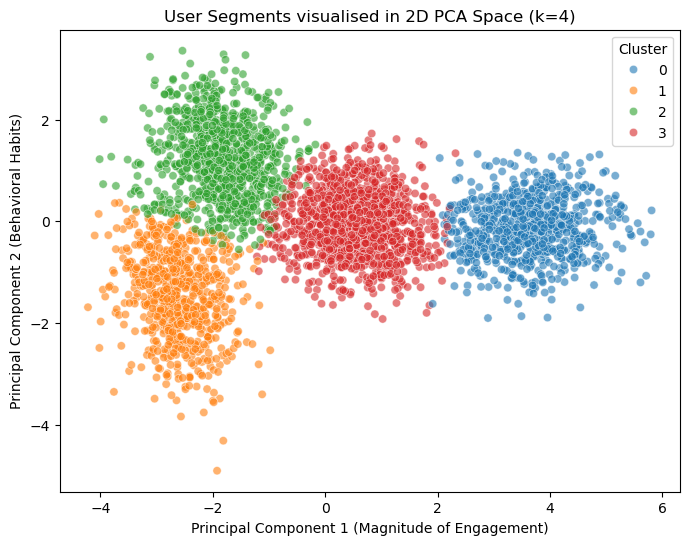


--- Cluster Characteristics ---
         orders_per_month  monthly_food_spend  discount_usage_rate  \
Cluster                                                              
0                   18.05             7652.17                 0.25   
1                    1.35              401.34                 0.29   
2                    3.86             1035.98                 0.55   
3                    8.92             2831.55                 0.34   

         avg_order_value  
Cluster                   
0                 420.72  
1                 220.42  
2                 258.68  
3                 316.72  


In [24]:
print("\n--- Q4: Clustering (K-Means) ---")

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='indigo')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


OPTIMAL_K = 4

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_pca)
df['Cluster'] = cluster_labels


plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='tab10', alpha=0.6)
plt.title(f'User Segments visualised in 2D PCA Space (k={OPTIMAL_K})')
plt.xlabel('Principal Component 1 (Magnitude of Engagement)')
plt.ylabel('Principal Component 2 (Behavioral Habits)')
plt.legend(title='Cluster')
plt.show()

print("\n--- Cluster Characteristics ---")
cluster_summary = df.groupby('Cluster')[['orders_per_month', 'monthly_food_spend', 'discount_usage_rate', 'avg_order_value']].mean()
print(cluster_summary.round(2))